In [55]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

dados_missoes = pd.DataFrame({
    'id_missao': [101, 102, 103],
    'equipe_membros': ["Gojo, Yuta", "Megumi", "Maki, Nobara, Panda"],
    'status': ["Concluída", "Concluída", None],
    # Horas gastas em 2023 e 2024 (Formato Wide)
    'horas_2023': [12.0, np.nan, 25.0],
    'horas_2024': [8.0, 15.0, np.nan]
})

# 2. Tabela Secundária de Cadastro dos Feiticeiros
dados_feiticeiros = pd.DataFrame({
    'nome': ["Gojo", "Yuta", "Megumi", "Maki", "Nobara", "Panda"],
    'nivel': ["Especial", "Especial", "1", "1", "3", "2"],
    'confiavel': [True, True, True, True, True, True]
})

df_missoes = pd.DataFrame(dados_missoes)
display(df_missoes)

df_feiticeiros = pd.DataFrame(dados_feiticeiros)
display(df_feiticeiros)

,id_missao,equipe_membros,status,horas_2023,horas_2024
0,101,"Gojo, Yuta",Concluída,12.0,8.0
1,102,Megumi,Concluída,NaN,15.0
2,103,"Maki, Nobara, Panda",None,25.0,NaN


,nome,nivel,confiavel
0,Gojo,Especial,True
1,Yuta,Especial,True
2,Megumi,1,True
3,Maki,1,True
4,Nobara,3,True
5,Panda,2,True


In [56]:
df_missoes['status'] = df_missoes['status'].fillna("Em Andamento")
df_missoes['horas_2023'] = df_missoes['horas_2023'].fillna(0.0)
df_missoes['horas_2024'] = df_missoes['horas_2024'].fillna(0.0)
df_missoes

,id_missao,equipe_membros,status,horas_2023,horas_2024
0,101,"Gojo, Yuta",Concluída,12.0,8.0
1,102,Megumi,Concluída,0.0,15.0
2,103,"Maki, Nobara, Panda",Em Andamento,25.0,0.0


In [57]:
dados_melt = pd.melt(
    df_missoes,
    id_vars=['id_missao','equipe_membros','status'],
    value_vars=['horas_2023','horas_2024'],
    var_name='ano',
    value_name='horas'
)
display(dados_melt)

,id_missao,equipe_membros,status,ano,horas
0,101,"Gojo, Yuta",Concluída,horas_2023,12.0
1,102,Megumi,Concluída,horas_2023,0.0
2,103,"Maki, Nobara, Panda",Em Andamento,horas_2023,25.0
3,101,"Gojo, Yuta",Concluída,horas_2024,8.0
4,102,Megumi,Concluída,horas_2024,15.0
5,103,"Maki, Nobara, Panda",Em Andamento,horas_2024,0.0


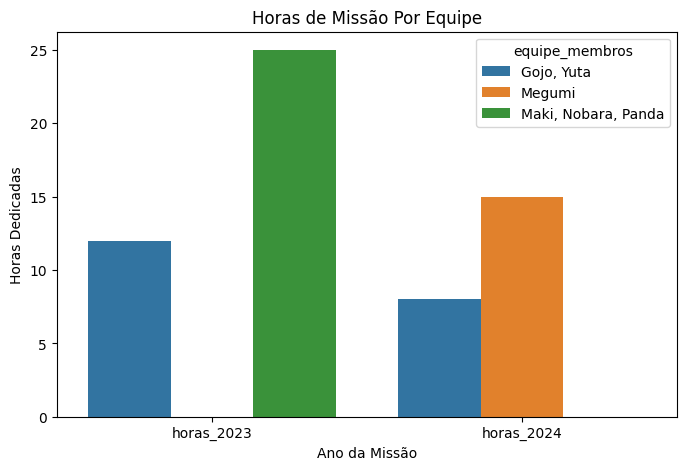

In [58]:
plt.figure(figsize=(8,5))

sns.barplot(data=dados_melt,
            x='ano',
            y='horas',
            hue='equipe_membros')

plt.title('Horas de Missão Por Equipe')
plt.xlabel('Ano da Missão')
plt.ylabel('Horas Dedicadas')

plt.show()

In [59]:
dados_melt['equipe_membros'] = dados_melt['equipe_membros'].str.split(', ')
dados_melt = dados_melt.explode('equipe_membros')
dados_melt

,id_missao,equipe_membros,status,ano,horas
0,101,Gojo,Concluída,horas_2023,12.0
0,101,Yuta,Concluída,horas_2023,12.0
1,102,Megumi,Concluída,horas_2023,0.0
2,103,Maki,Em Andamento,horas_2023,25.0
2,103,Nobara,Em Andamento,horas_2023,25.0
2,103,Panda,Em Andamento,horas_2023,25.0
3,101,Gojo,Concluída,horas_2024,8.0
3,101,Yuta,Concluída,horas_2024,8.0
4,102,Megumi,Concluída,horas_2024,15.0
5,103,Maki,Em Andamento,horas_2024,0.0


In [60]:
df_uniao = pd.merge(
    dados_melt,
    df_feiticeiros,
    left_on='equipe_membros',
    right_on='nome',
    how='inner'
)

display(df_uniao)

,id_missao,equipe_membros,status,ano,horas,nome,nivel,confiavel
0,101,Gojo,Concluída,horas_2023,12.0,Gojo,Especial,True
1,101,Yuta,Concluída,horas_2023,12.0,Yuta,Especial,True
2,102,Megumi,Concluída,horas_2023,0.0,Megumi,1,True
3,103,Maki,Em Andamento,horas_2023,25.0,Maki,1,True
4,103,Nobara,Em Andamento,horas_2023,25.0,Nobara,3,True
5,103,Panda,Em Andamento,horas_2023,25.0,Panda,2,True
6,101,Gojo,Concluída,horas_2024,8.0,Gojo,Especial,True
7,101,Yuta,Concluída,horas_2024,8.0,Yuta,Especial,True
8,102,Megumi,Concluída,horas_2024,15.0,Megumi,1,True
9,103,Maki,Em Andamento,horas_2024,0.0,Maki,1,True


In [61]:
df_limpo = df_uniao.drop(columns=['nome','confiavel'])
df_limpo

,id_missao,equipe_membros,status,ano,horas,nivel
0,101,Gojo,Concluída,horas_2023,12.0,Especial
1,101,Yuta,Concluída,horas_2023,12.0,Especial
2,102,Megumi,Concluída,horas_2023,0.0,1
3,103,Maki,Em Andamento,horas_2023,25.0,1
4,103,Nobara,Em Andamento,horas_2023,25.0,3
5,103,Panda,Em Andamento,horas_2023,25.0,2
6,101,Gojo,Concluída,horas_2024,8.0,Especial
7,101,Yuta,Concluída,horas_2024,8.0,Especial
8,102,Megumi,Concluída,horas_2024,15.0,1
9,103,Maki,Em Andamento,horas_2024,0.0,1


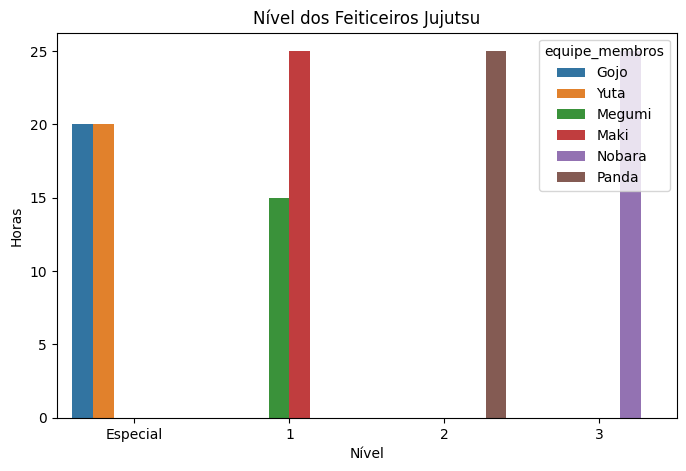

In [62]:
plt.figure(figsize=(8,5))
sns.barplot(df_limpo,
            x='nivel',
            y='horas',
            hue='equipe_membros',
            estimator='sum',
            errorbar=None,
            order=['Especial', '1', '2', '3'])

plt.title('Nível dos Feiticeiros Jujutsu')
plt.xlabel('Nível')
plt.ylabel('Horas')

plt.show()

In [63]:
df_cruzamento = pd.crosstab([df_limpo['equipe_membros'],df_limpo['nivel']], df_limpo['status'],margins=True)
df_cruzamento

,status,Concluída,Em Andamento,All
equipe_membros,nivel,,,
Gojo,Especial,2,0,2
Maki,1,0,2,2
Megumi,1,2,0,2
Nobara,3,0,2,2
Panda,2,0,2,2
Yuta,Especial,2,0,2
All,,6,6,12


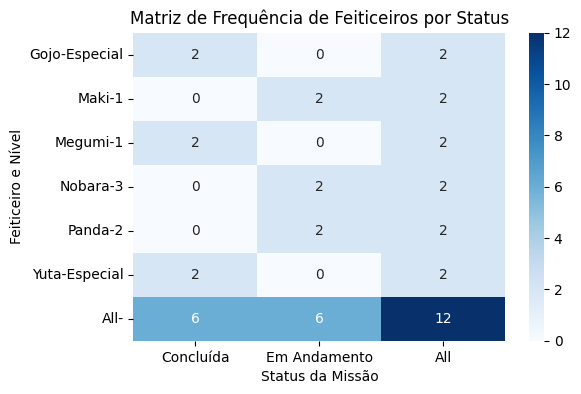

In [64]:
plt.figure(figsize=(6,4))

sns.heatmap(df_cruzamento,
            annot=True,
            fmt='d',
            cmap='Blues',
            cbar=True)

plt.title('Matriz de Frequência de Feiticeiros por Status')
plt.xlabel('Status da Missão')
plt.ylabel('Feiticeiro e Nível')

plt.show()

In [65]:
df_limpo[['horas']].describe()

,horas
count,12.000000
mean,10.833333
std,10.034788
min,0.000000
25%,0.000000
50%,10.000000
75%,17.500000
max,25.000000
